

#   **Nombre del Proyecto:** Analítica Predictiva Subasta Ganadera - Suganorte (Zarzal, Valle)
###   **Integrantes:** Jeferson Balcazar Gomez, Carlos Arturo Agudelo Garcia, Milton Vanegas Delgado.
###   **Fecha:** Sábado 11 de marzo del 2026
###   **Repositorio GitHub:** https://github.com/INTEP-Analitica-2026/Analitica-Predictiva-Subasta-Ganadera.git



####   **Problema de Negocio:** Las ventas del ganado en aproximadamente un 90% de los casos se realizan subastando el kilo de cada Lote, es por ello que decidimos enfocar la analitica predictiva de dichos precios, tomando como referencia aproximadamente 9 meses de datos de las ventas, contando con datos relevantes como el peso, la categoria(sexo), la procedencia (Regresión Lineal Simple y Múltiple). Implementamos el algortimo de HoltWinters con el fin de pronosticar el precio en un futuro muy cercano, lo que nos puede ayudar a precisar bases mas acertadas, gestionar la expectativa y por ultimo podria ayudarnos a proyectar rentabilidades por cantidades de Ganado por ingresar en las proximas semanas.

Por otra parte, enfocamos la analitica predictiva en predecir que variables influyen a que un lote tenga o no por lo menos una puja (Arbol de Decisión) y por ultimo, segmentamos los tipos de compradores (K-Means) con base a la relacion de cantidad de pujas por Kg en diferentes categorias de pesos del ganado.

#### **Por qué importa y a quien beneficia?:**
#####*Prediccion de precios y Arboles de Decision:* Al martillo y a la empresa: Conoce de antemano un rango de precios que le permite acortar tiempo al busca un precio mas acertado. A la empresa con el proveedor, al iniciar una base de precio justa en base a los datos(variables).

K-Means (Clustering): *Puede beneficia principalmente a la empresa, en su area de marketing y atencion al cliente*: Al tener segmentados los compradores se pueden crear estrategias de marketing cuando ingresen grandes volumenes de ganado con ciertas cualidades (Levante de la Costa, Ganado Gordo >= 450Kgs, Ganado Condicionado/Industrial). Actualmente existen listas de difusion con todos los tipos de compradores mezclados en ellas

## **Estructura del NoteBook:**


*   Carga, limpieza y EDA de Datos
*   Correlación de Variables
*   Regresión lineal Simple y Multiple
*   Métricas del Modelo




**Nota Importante:** `Los archivos CSV deben estar en Google Drive, en un enlace simbólico (Acceso Directo) en la carpeta raiz, llamado datasets/CSV`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Carga, Concatenación y Limpieza del Dataset**

In [2]:
import pandas as pd
import glob
import os
import re

pd.set_option('display.width', 2000)
# Definir la ruta donde están tus archivos en Drive
ruta_carpeta = '/content/drive/MyDrive/datasets/CSV/'

# Buscar todos los archivos (considerando .csv y .CSV)
archivos = glob.glob(ruta_carpeta + '*.csv') + glob.glob(ruta_carpeta + '*.CSV')

lista_dfs = []

# ==========================================
# PASO 1: Leer archivos y etiquetar la Fecha
# ==========================================
# Diccionario para traducir el texto del mes a su equivalente numérico
meses = {
    'ene': '01', 'feb': '02', 'mar': '03', 'abr': '04',
    'may': '05', 'jun': '06', 'jul': '07', 'ago': '08',
    'sep': '09', 'oct': '10', 'nov': '11', 'dic': '12'
}

# Buscamos el patrón en el nombre del archivo
patron_fecha = re.compile(r'([a-z]{3})_(\d{1,2})_(\d{4})')

for archivo in archivos:
    # Leemos con utf-8 para evitar el problema del caracter Â en las horas
    df = pd.read_csv(archivo, sep=';', dtype=str, encoding='utf-8')

    nombre_base = os.path.basename(archivo).lower()
    coincidencia = patron_fecha.search(nombre_base)

    if coincidencia:
        mes_str, dia, anio = coincidencia.groups()

        # 1. Buscamos el mes en el diccionario ('jun' se vuelve '06')
        mes_num = meses.get(mes_str, '01')

        # 2. Aseguramos que el día tenga dos dígitos ('4' se vuelve '04')
        dia_num = dia.zfill(2)

        # 3. Ensamblamos el formato dd/mm/yyyy
        df['Fecha'] = f"{dia_num}/{mes_num}/{anio}"

    else:
        df['Fecha'] = 'Fecha no identificada'

    lista_dfs.append(df)



# ==========================================
# PASO 2: Concatenar todo en 1 solo DataFrame
# ==========================================
df_total = pd.concat(lista_dfs, ignore_index=True)

# ==========================================
# PASO 3: Eliminar filas "Basura" y acentos
# ==========================================
# Esto elimina la fila de "FERIA No." y las del pie de página ("Lotes", "Sistema...")
df_total = df_total[pd.to_numeric(df_total['Lote'], errors='coerce').notnull()].copy()
df_total['Entrada'] = df_total['Entrada'].str.replace('Â', '', regex=False)

# ==========================================
# PASO 4: Eliminar columnas "Basura"
# ==========================================
# Quitamos columnas que no vamos a usar en la regresion lineal
columnas_basura = ['Lote', 'Observaciones', 'P.Total']
df_total = df_total.drop(columns=columnas_basura, errors='ignore')

# ==========================================
# PASO 5: Limpieza de números y Filtro Temporal
# ==========================================
# Ahora solo limpiamos los puntos de miles en Cant., P.Prom, $Base y $Final
columnas_numericas = ['Cant.', 'P.Prom', '$Base', '$Final']
for col in columnas_numericas:
    if col in df_total.columns:
        df_total[col] = pd.to_numeric(df_total[col].astype(str).str.replace('.', '', regex=False), errors='coerce')

# Filtro temporal: Solo ventas por kilo (entre 0 y 19.999)
df_total = df_total[(df_total['$Final'] > 0) & (df_total['$Final'] <= 19999)]

# Quitamos filas con datos vacíos en las columnas clave que nos quedan
df_total = df_total.dropna(subset=['$Base','$Final', 'P.Prom', 'Cant.', 'Sexo'])



# **Analisis Exploratorio (EDA):**

In [3]:
# Verificamos los resultados
print(f"Shape DF: {df_total.shape}")
print("\n==================INFO()==================")
df_total.info()
print("\n==================DESCRIBE()==================")
df_total.describe().round(2)



Shape DF: (11254, 8)

==================INFO()==================
<class 'pandas.core.frame.DataFrame'>
Index: 11254 entries, 1 to 13589
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Sexo         11254 non-null  object
 1   Cant.        11254 non-null  int64 
 2   P.Prom       11254 non-null  int64 
 3   Procedencia  11254 non-null  object
 4   Entrada      11254 non-null  object
 5   $Base        11254 non-null  int64 
 6   $Final       11254 non-null  int64 
 7   Fecha        11254 non-null  object
dtypes: int64(4), object(4)
memory usage: 791.3+ KB

==================DESCRIBE()==================


,Cant.,P.Prom,$Base,$Final
count,11254.00,11254.00,11254.00,11254.00
mean,1.93,250.88,7439.97,8492.35
std,1.75,122.55,1768.35,1918.53
min,1.00,20.00,89.00,800.00
25%,1.00,150.00,6500.00,7500.00
50%,1.00,235.00,7800.00,8400.00
75%,2.00,340.00,8500.00,9400.00
max,12.00,780.00,15000.00,19500.00


In [4]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df_total.isnull().sum())
print(f"\n✅ Total de nulos: {df_total.isnull().sum().sum()}")

Valores nulos por columna:
Sexo           0
Cant.          0
P.Prom         0
Procedencia    0
Entrada        0
$Base          0
$Final         0
Fecha          0
dtype: int64

✅ Total de nulos: 0


# **Visualización de Graficos**

Top 5 categorías identificadas: ['HL', 'ML', 'VH', 'HV', 'TR']
------------------------------------------------------------


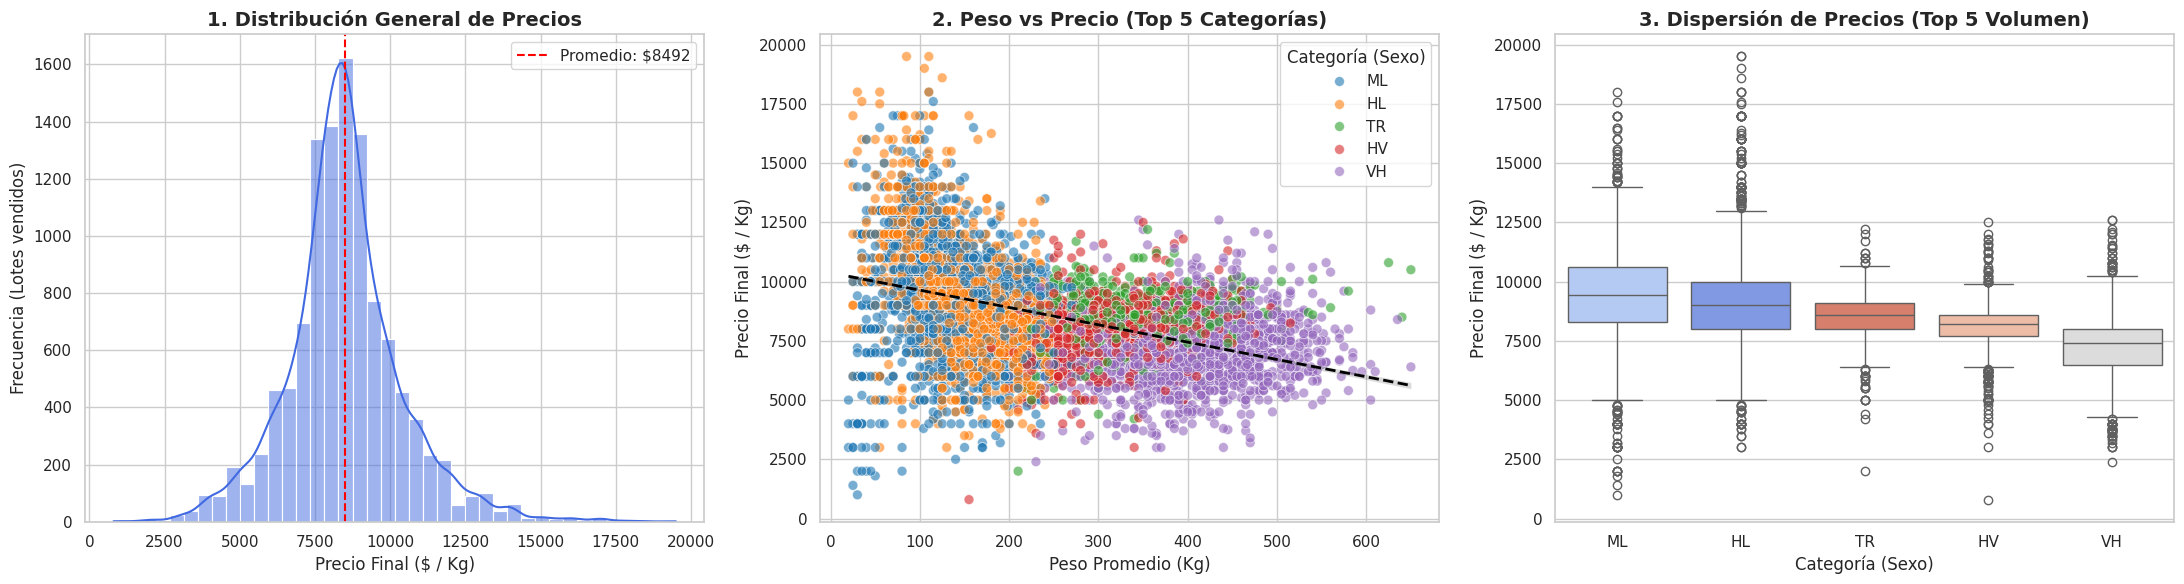

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Configuración de estilo visual
sns.set_theme(style="whitegrid")

# ==========================================
# PASO 1: Preparar el Top 5 para los gráficos 2 y 3
# ==========================================
top_5_sexos_labels = df_total['Sexo'].value_counts().head(5).index
df_top5 = df_total[df_total['Sexo'].isin(top_5_sexos_labels)].copy()
orden_top5 = df_top5.groupby('Sexo')['$Final'].median().sort_values(ascending=False).index

print(f"Top 5 categorías identificadas: {list(top_5_sexos_labels)}")
print("-" * 60)

# Creamos el lienzo para los 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# ==========================================
# GRÁFICO 1: Distribución general (TODO EL DATASET)
# ==========================================
sns.histplot(data=df_total, x='$Final', bins=40, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('1. Distribución General de Precios', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio Final ($ / Kg)', fontsize=12)
axes[0].set_ylabel('Frecuencia (Lotes vendidos)', fontsize=12)

promedio = df_total['$Final'].mean()
axes[0].axvline(promedio, color='red', linestyle='--', label=f'Promedio: ${promedio:.0f}')
axes[0].legend()

# ==========================================
# GRÁFICO 2: Peso vs Precio (SOLO TOP 5)
# ==========================================
sns.scatterplot(data=df_top5, x='P.Prom', y='$Final', hue='Sexo',
                hue_order=orden_top5, alpha=0.6, palette='tab10', s=50, ax=axes[1])

# Línea de tendencia global para el Top 5
sns.regplot(data=df_top5, x='P.Prom', y='$Final', scatter=False,
            color='black', line_kws={"linestyle":"--", "linewidth":2}, ax=axes[1])

axes[1].set_title('2. Peso vs Precio (Top 5 Categorías)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Peso Promedio (Kg)', fontsize=12)
axes[1].set_ylabel('Precio Final ($ / Kg)', fontsize=12)
axes[1].legend(title='Categoría (Sexo)')

# ==========================================
# GRÁFICO 3: Rangos de Precio por Categoría (SOLO TOP 5)
# ==========================================
# LÍNEA CORREGIDA: Se agregó hue='Sexo' y legend=False
sns.boxplot(data=df_top5, x='Sexo', y='$Final', hue='Sexo', order=orden_top5, palette='coolwarm', legend=False, ax=axes[2])

# Puntos de densidad (stripplot)
if len(df_top5) < 5000:
    sns.stripplot(data=df_top5, x='Sexo', y='$Final', hue='Sexo', order=orden_top5,
                  palette='dark:black', size=2, alpha=0.3, jitter=True, legend=False, ax=axes[2])

axes[2].set_title('3. Dispersión de Precios (Top 5 Volumen)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Categoría (Sexo)', fontsize=12)
axes[2].set_ylabel('Precio Final ($ / Kg)', fontsize=12)

# Ajuste final
plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# Convertimos 'Sexo' a numérico (Dummies, variable Categorica)
# ==========================================
df_total = pd.get_dummies(df_total, columns=['Sexo'], drop_first=True)

print(f"Archivos CSV procesados: {len(lista_dfs)}")
print(f"Dataset listo. Total de registros finales: {len(df_total)}")
print("\nUltimas 5 filas del dataset consolidado y limpio:")

# Reiniciar el índice para que vuelva a ser continuo de 0 a 3691
df_total = df_total.reset_index(drop=True)
df_total.tail(5)

Archivos CSV procesados: 40
Dataset listo. Total de registros finales: 11254

Ultimas 5 filas del dataset consolidado y limpio:


,Cant.,P.Prom,Procedencia,Entrada,$Base,$Final,Fecha,Sexo_BH,Sexo_HL,Sexo_HV,Sexo_MC,Sexo_ML,Sexo_TI,Sexo_TO,Sexo_TR,Sexo_VH,Sexo_VI,Sexo_VP
11249,1,215,RESTREPO,03:12 p. m.,7500,12500,16/07/2025,False,True,False,False,False,False,False,False,False,False,False
11250,1,160,RESTREPO,03:12 p. m.,6000,9000,16/07/2025,False,True,False,False,False,False,False,False,False,False,False
11251,1,125,RESTREPO,03:13 p. m.,10000,12000,16/07/2025,False,True,False,False,False,False,False,False,False,False,False
11252,1,185,RESTREPO,03:13 p. m.,8000,9750,16/07/2025,False,True,False,False,False,False,False,False,False,False,False
11253,1,185,RESTREPO,03:13 p. m.,8000,9500,16/07/2025,False,True,False,False,False,False,False,False,False,False,False


# **Matriz de Correalacion:** Vemos que variables influyen en nuestra variable objetivo

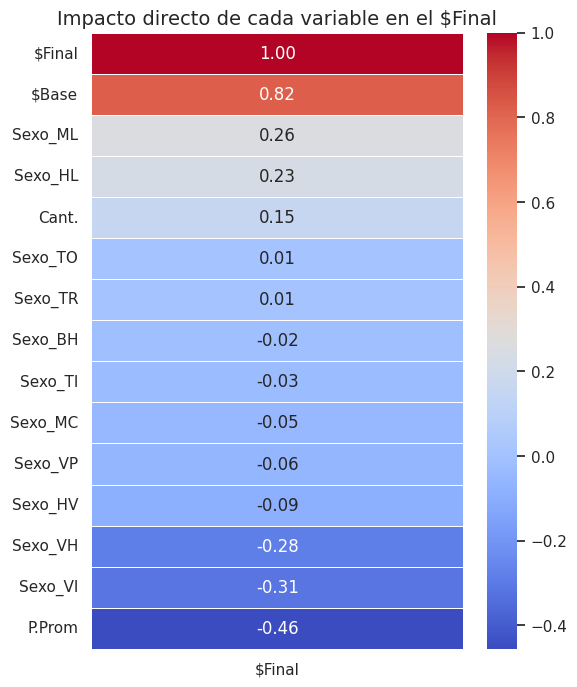

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculamos la correlación SOLO contra la columna '$Final' y la ordenamos
correlacion_objetivo = df_total.corr(numeric_only=True)[['$Final']].sort_values(by='$Final', ascending=False)

# 2. Configuramos el tamaño (más angosto porque es una sola columna)
plt.figure(figsize=(6, 8))

# 3. Dibujamos el Heatmap
sns.heatmap(correlacion_objetivo, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# 4. Títulos
plt.title('Impacto directo de cada variable en el $Final', fontsize=14)
plt.show()

Interpretaciones:

*   Peso Promedio (P. Prom.): Entre mas pese el lote, menor es el valor por Kg, aunque su valor final sea alto
*   Las categorias de Machos de Levante (ML) y Hembra de Levante (HL) son las que tienen mas altos valor por Kg.
*   En contra Parte, las Vacas Horras (VH) y las Vacas Industriales (VI) son las categorias que tienden a tener menor precio por Kg de todo el Dataset
*   Se evidencia el tamaño del lote (Cant.) tiene una ligera influencia en el valor, pueda ser eficiencia de transporte o unirformidad en los animales



--- RESULTADOS: REGRESIÓN LINEAL SIMPLE ---
Fórmula: Precio = (-7.24 * Peso) + 10322.39
--------------------------------------------------
Por cada kilo extra de peso, el precio cambia en: $-7.24
Precisión del modelo (R^2): 0.1819 (Un 18.2%)
--------------------------------------------------


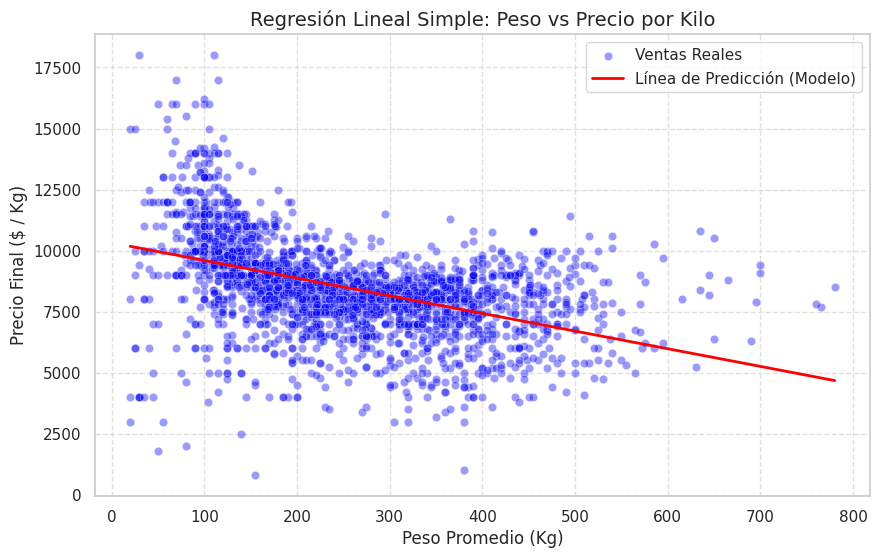

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# 1. DEFINIR VARIABLES
# ==========================================
# X (Independiente): Peso Promedio. Se usa doble corchete porque scikit-learn requiere una tabla 2D.
X = df_total[['P.Prom']]
# y (Dependiente/Objetivo): Precio Final
y = df_total['$Final']

# ==========================================
# 2. DIVIDIR DATOS (Entrenamiento y Prueba)
# ==========================================
# Separamos 80% para entrenar y 20% para probar. random_state=42 garantiza que la división sea siempre igual.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 3. CREAR Y ENTRENAR EL MODELO
# ==========================================
modelo_simple = LinearRegression()
modelo_simple.fit(X_train, y_train) # Aquí ocurre la magia matemática

# ==========================================
# 4. EVALUAR EL MODELO
# ==========================================
# Le pedimos que prediga los precios del 20% de datos que reservamos para la prueba
y_pred = modelo_simple.predict(X_test)

# Extraemos los componentes de la fórmula: y = (Pendiente * X) + Intercepto
intercepto = modelo_simple.intercept_
coeficiente = modelo_simple.coef_[0]
r2 = r2_score(y_test, y_pred) # El R^2 nos dice qué porcentaje de la variación explica el modelo

print("--- RESULTADOS: REGRESIÓN LINEAL SIMPLE ---")
print(f"Fórmula: Precio = ({coeficiente:.2f} * Peso) + {intercepto:.2f}")
print("-" * 50)
print(f"Por cada kilo extra de peso, el precio cambia en: ${coeficiente:.2f}")
print(f"Precisión del modelo (R^2): {r2:.4f} (Un {(r2*100):.1f}%)")
print("-" * 50)

# ==========================================
# 5. GRAFICAR EL RESULTADO
# ==========================================
plt.figure(figsize=(10, 6))

# Puntos reales (Pintamos los datos de prueba)
sns.scatterplot(x=X_test['P.Prom'], y=y_test, color='blue', alpha=0.4, label='Ventas Reales')

# La línea de predicción del modelo
sns.lineplot(x=X_test['P.Prom'], y=y_pred, color='red', linewidth=2, label='Línea de Predicción (Modelo)')

plt.title('Regresión Lineal Simple: Peso vs Precio por Kilo', fontsize=14)
plt.xlabel('Peso Promedio (Kg)', fontsize=12)
plt.ylabel('Precio Final ($ / Kg)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Aunque el peso en Kg del lote influye en su valor por Kg no llegamos ni a un 20%, oscila entre un 14% a un 18%, es decir, hay otras variables que influyen en el precio (Cantidad, Procedencia, Hora de llegada a la Subasta), procedemos a implementar la **Regresion Lineal Multiple** para subir ese porcentaje

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# 1. PREPARAR LAS NUEVAS CATEGORÍAS
# ==========================================
# Extraemos solo la "Hora" de la entrada (ej. "06:13 a. m." -> "06")
df_total['Hora_Entrada'] = df_total['Entrada'].astype(str).str.split(':').str[0]
df_total['Hora_Entrada'] = 'Hora_' + df_total['Hora_Entrada']

# Limpieza rápida por si hay vacíos
df_total['Procedencia'] = df_total['Procedencia'].fillna('Desconocida')

# Convertimos Procedencia y Hora a variables Dummies (True/False)
df_modelo = pd.get_dummies(df_total, columns=['Procedencia', 'Hora_Entrada'], drop_first=True)

# ==========================================
# 2. DEFINIR VARIABLES (X e y)
# ==========================================
# Recolectamos TODAS las variables que nos interesan
columnas_sexo = [col for col in df_modelo.columns if col.startswith('Sexo_')]
columnas_procedencia = [col for col in df_modelo.columns if col.startswith('Procedencia_')]
columnas_hora = [col for col in df_modelo.columns if col.startswith('Hora_Entrada_')]

# Unimos Peso, Cantidad y todas las dummies
columnas_x = ['P.Prom', 'Cant.'] + columnas_sexo + columnas_procedencia + columnas_hora

X_multiple = df_modelo[columnas_x]
y = df_modelo['$Final']

# ==========================================
# 3. ENTRENAR EL MODELO
# ==========================================
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multiple, y, test_size=0.2, random_state=42)

modelo_multiple = LinearRegression()
modelo_multiple.fit(X_train_m, y_train_m)

# ==========================================
# 4. EVALUAR EL MODELO
# ==========================================
r2_train_m = r2_score(y_train_m, modelo_multiple.predict(X_train_m))
r2_test_m = r2_score(y_test_m, modelo_multiple.predict(X_test_m))

print("--- RESULTADOS: REGRESIÓN MÚLTIPLE COMPLETA ---")
print(f"R² en entrenamiento: {r2_train_m:.4f}")
print(f"R² en prueba:        {r2_test_m:.4f}")
print("-" * 50)

# ==========================================
# 5. RANKING DE IMPACTO (TOP 15)
# ==========================================
# Creamos una tabla para ordenar qué variables pesan más en el modelo
df_impactos = pd.DataFrame({
    'Variable': columnas_x,
    'Impacto_Pesos': modelo_multiple.coef_
})

# Ordenamos por el valor absoluto (para ver los que más suman o más restan)
df_impactos['Magnitud'] = df_impactos['Impacto_Pesos'].abs()
df_impactos = df_impactos.sort_values(by='Magnitud', ascending=False).head(20)

print("TOP 20: Variables que más mueven el precio final:")
for index, row in df_impactos.iterrows():
    impacto_str = f"+${row['Impacto_Pesos']:.2f}" if row['Impacto_Pesos'] > 0 else f"-${abs(row['Impacto_Pesos']):.2f}"
    print(f" > {row['Variable'].ljust(35)}: {impacto_str}")

--- RESULTADOS: REGRESIÓN MÚLTIPLE COMPLETA ---
R² en entrenamiento: 0.3506
R² en prueba:        0.3054
--------------------------------------------------
TOP 20: Variables que más mueven el precio final:
 > Procedencia_TOTORÓ CAUCA           : +$6112.74
 > Procedencia_PRESIDENTE             : +$5434.14
 > Procedencia_EL GUAVIARE-DIRECT     : +$4889.02
 > Procedencia_SAN VICENTE FERRER     : +$4456.77
 > Procedencia_HIGUERON               : +$3946.13
 > Procedencia_PATIA CAUCA            : +$3880.74
 > Procedencia_LA GRAN HACIENDA L     : +$3849.60
 > Procedencia_ARMENIA                : +$3781.04
 > Procedencia_LA VIRGINIA            : +$3644.81
 > Procedencia_TRUJILLLO              : +$3612.66
 > Procedencia_AMAGA                  : +$3459.42
 > Procedencia_SAN JOSE               : +$3329.46
 > Procedencia_BAGALAGRANDE           : +$3308.77
 > Procedencia_CERRITO                : +$3293.33
 > Procedencia_POPAYAN                : +$3218.50
 > Procedencia_HACIENDA EL LIBANO     : +$307

**Interpretracion de la Regresion Lineal Multiple:**

*   Pasamos de un 18% a un 29% de explicar el comportamiento del precio, agregando variables como la procedencia y hora de llegada, el 71% restante son variables que no tenemos a la mano como por ejemplo La Raza, el Estado Corporal, Biotipo (Leche/Carne), en el Caso de las Vacas para tema de precio influyen mucho en el precio factores reproductivos que no tenemos en el momento (Calidad de Ubres, Cantidad de Partos, confirmacion de Preñez)
*   Procedencia LA VIRGINIA tiene la mayor influencia sobre el Kg: 5.285 procedencias de ciertas Haciendas (Procedencia HACIENDA EL LIBANO) influyen en el precio, problamente por su reputacion entre los ganaderos
*   Procedencia DOVIO y la Categoria de Vaca Industrial son altamente influyentes en precios bajos , menos 4,082 y  menos 4,141 respectivamente
*   La hora de entrada, de forma general, no tiene mayor influencia en el precio



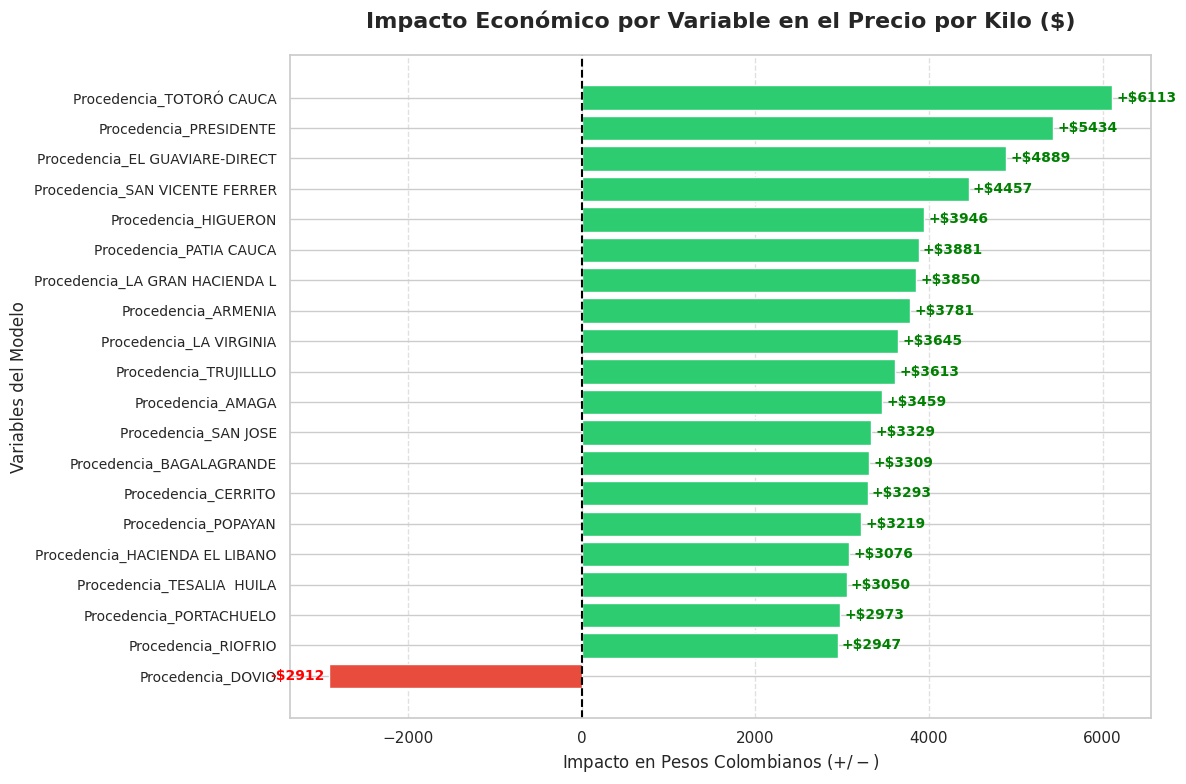

In [10]:
# Usaremos el df_impactos que creamos en el bloque anterior con el Top 15
# Ordenamos de menor a mayor impacto para que el gráfico se dibuje de arriba hacia abajo
df_grafico = df_impactos.sort_values(by='Impacto_Pesos', ascending=True)

# Asignar colores: Verde para impacto positivo (sube el precio), Rojo para negativo (baja el precio)
colores = ['#e74c3c' if x < 0 else '#2ecc71' for x in df_grafico['Impacto_Pesos']]

plt.figure(figsize=(12, 8))

# Crear el gráfico de barras horizontales
bars = plt.barh(df_grafico['Variable'], df_grafico['Impacto_Pesos'], color=colores)

# Agregar la línea del cero (Precio Base)
plt.axvline(x=0, color='black', linewidth=1.5, linestyle='--')

# Títulos y etiquetas
plt.title('Impacto Económico por Variable en el Precio por Kilo ($)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Impacto en Pesos Colombianos (+$ / -$)', fontsize=12)
plt.ylabel('Variables del Modelo', fontsize=12)

# Formato para que el texto de las variables (eje Y) sea más limpio
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Agregar el valor exacto en texto al lado de cada barra
for bar in bars:
    valor = bar.get_width()
    # Ajustar la posición del texto dependiendo si es positivo o negativo
    if valor > 0:
        plt.text(valor + 50, bar.get_y() + bar.get_height()/2, f'+${valor:.0f}',
                 va='center', fontsize=10, color='green', fontweight='bold')
    else:
        plt.text(valor - 50, bar.get_y() + bar.get_height()/2, f'-${abs(valor):.0f}',
                 va='center', ha='right', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calcular métricas para ambos modelos
# Simple: usa X_test / y_test  |  Múltiple: usa X_test_m / y_test_m
y_pred_simple = modelo_simple.predict(X_test)
y_pred_multi = modelo_multiple.predict(X_test_m)

metricas = pd.DataFrame({
    'Métrica': ['R² (Test)', 'MAE', 'RMSE', 'MSE'],
    'Regresión Simple': [
        r2_score(y_test, y_pred_simple),
        mean_absolute_error(y_test, y_pred_simple),
        np.sqrt(mean_squared_error(y_test, y_pred_simple)),
        mean_squared_error(y_test, y_pred_simple)
    ],
    'Regresión Múltiple': [
        r2_score(y_test_m, y_pred_multi),
        mean_absolute_error(y_test_m, y_pred_multi),
        np.sqrt(mean_squared_error(y_test_m, y_pred_multi)),
        mean_squared_error(y_test_m, y_pred_multi)
    ]
})

metricas = metricas.round(4)
print("=" * 65)
print("COMPARACIÓN DE MODELOS")
print("=" * 65)
print(metricas.to_string(index=False))

mejora_r2 = (metricas.iloc[0, 2] - metricas.iloc[0, 1]) / metricas.iloc[0, 1] * 100
print(f"\n📈 Mejora del R² al pasar de simple a múltiple: +{mejora_r2:.1f}%")
print(f"\n💡 CONCLUSIÓN: La regresión múltiple explica el")
print(f"   {metricas.iloc[0, 2]*100:.1f}% de la variabilidad vs {metricas.iloc[0, 1]*100:.1f}% de la simple.")

COMPARACIÓN DE MODELOS
  Métrica  Regresión Simple  Regresión Múltiple
R² (Test)            0.1819              0.3054
      MAE         1276.0364           1163.6465
     RMSE         1783.4268           1643.3434
      MSE      3180611.3081        2700577.5768

📈 Mejora del R² al pasar de simple a múltiple: +67.9%

💡 CONCLUSIÓN: La regresión múltiple explica el
   30.5% de la variabilidad vs 18.2% de la simple.


# **Probemos el modelo con algunos datos aleatorios:**

In [12]:
import pandas as pd

# Creamos una función reutilizable
def predecir_precio(peso, cantidad, sexo='Ninguno', procedencia='Desconocida', hora='00'):

    # 1. Crear un diccionario con todas las columnas del modelo original, llenas de ceros (False)
    datos_nuevos = {columna: 0 for columna in columnas_x}

    # 2. Asignar los valores numéricos directos que ingresaste
    datos_nuevos['P.Prom'] = peso
    datos_nuevos['Cant.'] = cantidad

    # 3. Encender (poner en 1/True) las variables Dummy correspondientes
    columna_sexo = f'Sexo_{sexo}'
    if columna_sexo in datos_nuevos:
        datos_nuevos[columna_sexo] = 1

    columna_procedencia = f'Procedencia_{procedencia}'
    if columna_procedencia in datos_nuevos:
        datos_nuevos[columna_procedencia] = 1

    columna_hora = f'Hora_Entrada_{hora}'
    if columna_hora in datos_nuevos:
        datos_nuevos[columna_hora] = 1

    # 4. Convertir nuestro diccionario en un DataFrame de 1 sola fila
    df_prediccion = pd.DataFrame([datos_nuevos])

    # 5. Hacer la predicción
    precio_estimado = modelo_multiple.predict(df_prediccion)[0]

    return precio_estimado

# ==========================================
#  PROBEMOS CON NUESTROS DATOS
# ==========================================
# Escenario 1: (Macho de Levante, 160 kg, Lote de 3)
precio_1 = predecir_precio(peso=60, cantidad=1, sexo='VH')
print(f"Predicción Escenario 1 (ML, 160kg, 3 anim.): ${precio_1:,.2f} por Kg")

# Escenario 2: Agregando la procedencia "Premium" que descubrimos
precio_2 = predecir_precio(peso=160, cantidad=3, sexo='ML', procedencia='LA VIRGINIA')
print(f"Predicción Escenario 2 (Igual, pero de LA VIRGINIA): ${precio_2:,.2f} por Kg")

# Escenario 3: Una Vaca de Invernada pesada de Dovio (El peor escenario según el modelo)
precio_3 = predecir_precio(peso=450, cantidad=1, sexo='VI', procedencia='DOVIO')
print(f"Predicción Escenario 3 (VI, 450kg, de DOVIO): ${precio_3:,.2f} por Kg")

# Escenario 4: Tu consulta específica
precio_vp = predecir_precio(peso=540, cantidad=1, sexo='VH', procedencia='ARMENIA')

print(f"Predicción Vaca Parida (440kg, 1 animal): ${precio_vp:,.2f} por Kg")

Predicción Escenario 1 (ML, 160kg, 3 anim.): $7,008.41 por Kg
Predicción Escenario 2 (Igual, pero de LA VIRGINIA): $10,803.21 por Kg
Predicción Escenario 3 (VI, 450kg, de DOVIO): $-379.78 por Kg
Predicción Vaca Parida (440kg, 1 animal): $8,089.57 por Kg


# **Series Temporales (Holt-Winters)**

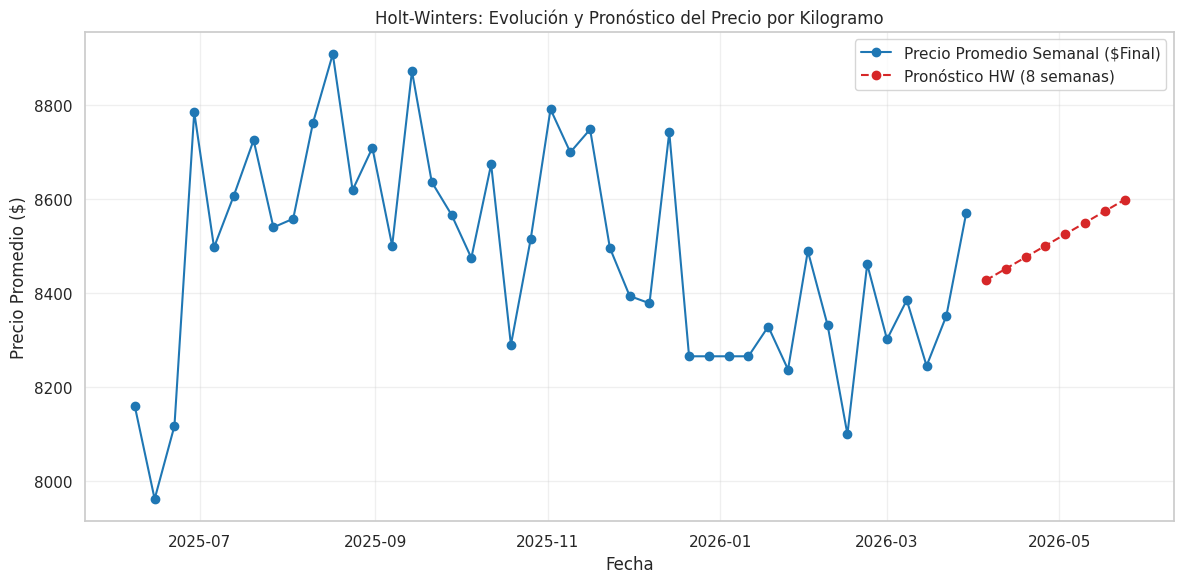

In [13]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ==========================================
# 1. PREPARACIÓN Y CUMPLIMIENTO DE ESTRUCTURA
# ==========================================
# Trabajamos sobre una copia para no alterar tu df_total general
df_ts = df_total.copy()

# Aseguramos que el precio final sea un número procesable
df_ts['$Final'] = pd.to_numeric(df_ts['$Final'], errors='coerce')

# Cumplimos con la regla de negocio: asignamos explícitamente el tipo de venta
# (Dado que el dataset ya viene filtrado sin remates, todos son por Kilo)
df_ts['Venta'] = 'K'

# ==========================================
# 2. CONVERSIÓN DE FECHA (Nuevo formato)
# ==========================================
# Pandas ahora puede leer directamente tu formato dd/mm/yyyy
df_ts['Fecha_TS'] = pd.to_datetime(df_ts['Fecha'], dayfirst=True, errors='coerce')

# Limpiamos filas con fechas inválidas por seguridad
df_ts = df_ts.dropna(subset=['Fecha_TS'])

# ==========================================
# 3. CREACIÓN DE LA SERIE TEMPORAL
# ==========================================
# Establecemos el índice temporal y ordenamos cronológicamente
df_ts.set_index('Fecha_TS', inplace=True)
df_ts.sort_index(inplace=True)

# Agrupamos por semana sacando el promedio del precio final
precio_promedio_semanal = df_ts['$Final'].resample('W').mean()

# Rellenamos posibles semanas sin datos con el valor anterior
precio_promedio_semanal = precio_promedio_semanal.ffill()

# ==========================================
# 4. PRONÓSTICO HW Y VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(12, 6))

# Trazamos la línea histórica real
plt.plot(precio_promedio_semanal.index, precio_promedio_semanal.values,
         label='Precio Promedio Semanal ($Final)', color='#1f77b4', marker='o')

# El seguro: Solo proyecta si hay datos de más de una semana
if len(precio_promedio_semanal) > 1:
    modelo_hw = ExponentialSmoothing(
        precio_promedio_semanal,
        trend='add',
        seasonal=None,
        initialization_method="estimated"
    ).fit()

    pronostico = modelo_hw.forecast(8) # Predicción de 8 semanas

    plt.plot(pronostico.index, pronostico.values,
             label='Pronóstico HW (8 semanas)', color='#d62728', linestyle='--', marker='o')
else:
    print("Nota: El dataset actual solo contiene datos de una semana. Se necesita más historial para generar el pronóstico.")

# Configuración visual
plt.title('Holt-Winters: Evolución y Pronóstico del Precio por Kilogramo')
plt.xlabel('Fecha')
plt.ylabel('Precio Promedio ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# **Metricas del Modelo Anterior:**

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ==========================================
# EVALUACIÓN DEL MODELO (BACKTESTING)
# ==========================================
# 1. Separamos las últimas 4 semanas (1 mes) como nuestro "Examen Final"
semanas_prueba = 4
train_hw = precio_promedio_semanal[:-semanas_prueba]
test_hw = precio_promedio_semanal[-semanas_prueba:]

# 2. Entrenamos el modelo SOLO con el pasado
modelo_eval = ExponentialSmoothing(
    train_hw,
    trend='add',
    seasonal=None,
    initialization_method="estimated"
).fit()

# 3. Le pedimos que prediga ese mes que le escondimos
predicciones_hw = modelo_eval.forecast(semanas_prueba)

# 4. Calculamos las 3 métricas de oro
mae_hw = mean_absolute_error(test_hw, predicciones_hw)
rmse_hw = np.sqrt(mean_squared_error(test_hw, predicciones_hw))
# MAPE (Error Porcentual Absoluto Medio) - La métrica favorita de los gerentes
mape_hw = np.mean(np.abs((test_hw - predicciones_hw) / test_hw)) * 100

print("--- MÉTRICAS DE PRECISIÓN: HOLT-WINTERS ---")
print(f"MAE  (Error en Pesos):      ± ${mae_hw:.2f} por Kilo")
print(f"RMSE (Penalización picos):  ± ${rmse_hw:.2f} por Kilo")
print(f"MAPE (Error Porcentual):    ± {mape_hw:.2f}%")

--- MÉTRICAS DE PRECISIÓN: HOLT-WINTERS ---
MAE  (Error en Pesos):      ± $125.41 por Kilo
RMSE (Penalización picos):  ± $159.88 por Kilo
MAPE (Error Porcentual):    ± 1.48%


Cierran a la baja en diciembre, comienza enero y empieza a ver un ascenco leve hasta abril, pasa semana santa y los precios suben aun mas , hasta 1 o 2da semana de junio, ahi empieza a descender, porque paralela empieza cocecha de ternero, despues de junio los precios van a la baja

# **Por qué elegimos Holt-Winters sobre SARIMA?**


1.   SARIMA idealmente requiere de datos anuales 2 a 3 años como minimo, Holt-Winters a traves de su parametro seasonal=None nos permite abarcar menos rango de tiempo (jun_2025 - marzo_2026)
2.   SARIMA exige que que la serie sea Estacionaria, el precio del ganado por variables internas o externas puede tener unos picos agresivos de precios en algunas temporadas (Volatilidad)



# **Arboles de Decisión (Clasificación)**

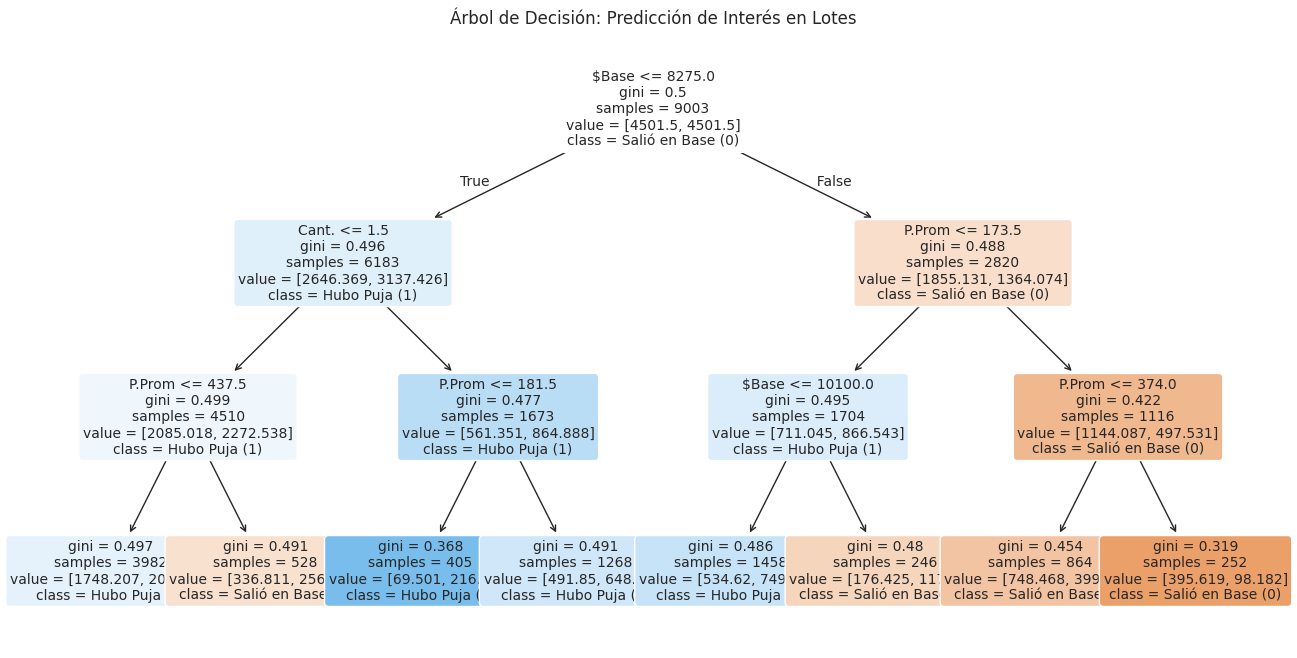

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Aislar las 7 columnas seleccionadas
columnas_estrictas = ['Cant.', 'P.Prom', 'Procedencia', 'Entrada', '$Base', '$Final', 'Fecha']
df_arbol = df_total[columnas_estrictas].copy()

# Asegurar que los precios sean numéricos para evitar errores matemáticos
df_arbol['$Final'] = pd.to_numeric(df_arbol['$Final'], errors='coerce')
df_arbol['$Base'] = pd.to_numeric(df_arbol['$Base'], errors='coerce')

# 2. Crear la Variable Objetivo (1 = Hubo Puja, 0 = Sin Puja)
df_arbol['Hubo_Puja'] = (df_arbol['$Final'] > df_arbol['$Base']).astype(int)

# 3. Limpiar las Pistas (Variables X)
# Descartamos las variables de texto/tiempo y el $Final (para evitar la fuga de datos)
df_arbol = df_arbol.drop(columns=['Fecha', 'Entrada', '$Final'])

# Traducimos la Procedencia a formato binario (Verdadero/Falso)
df_arbol = pd.get_dummies(df_arbol, columns=['Procedencia'], drop_first=True)

# 4. Separar Pistas (X) y Resultados (y)
X = df_arbol.drop(columns=['Hubo_Puja'])
y = df_arbol['Hubo_Puja']

# 5. Entrenar el Modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# max_depth=3 hace que el árbol sea pequeño, conciso y fácil de leer
modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
modelo_arbol.fit(X_train, y_train)

# 6. Dibujar el Árbol
plt.figure(figsize=(16, 8))
plot_tree(
    modelo_arbol,
    feature_names=X.columns,
    class_names=['Salió en Base (0)', 'Hubo Puja (1)'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión: Predicción de Interés en Lotes")
plt.show()

# **Interpretacion:**

1.   El algoritmo encontró un precio como punto de infleccion 181.5Kgs (punto de encuentro de animales de Levante y Destete).
2.   Si el lote está entre los 32.5 y 181.5 y ademas el Martillo, (Subastador), inicia con un valor no muy alto menor o igual a 10.100, hay probabilidades muy altas que hayan muchas pujas por dicho lote, precios base de esos rangos de pesos mayores a 10.100 el comprador pierde interes y espera que baje la base
3. Para animales mayores a 181.5 y con precios base iguales o inferiores a $8.275 tienen mejor probabilidades de puja, de igual forma, para animales pesados, si el precio supeera el umbral de los 8.275 la probabilidad de puja es muy baja





# **Clustering (K-Means)**


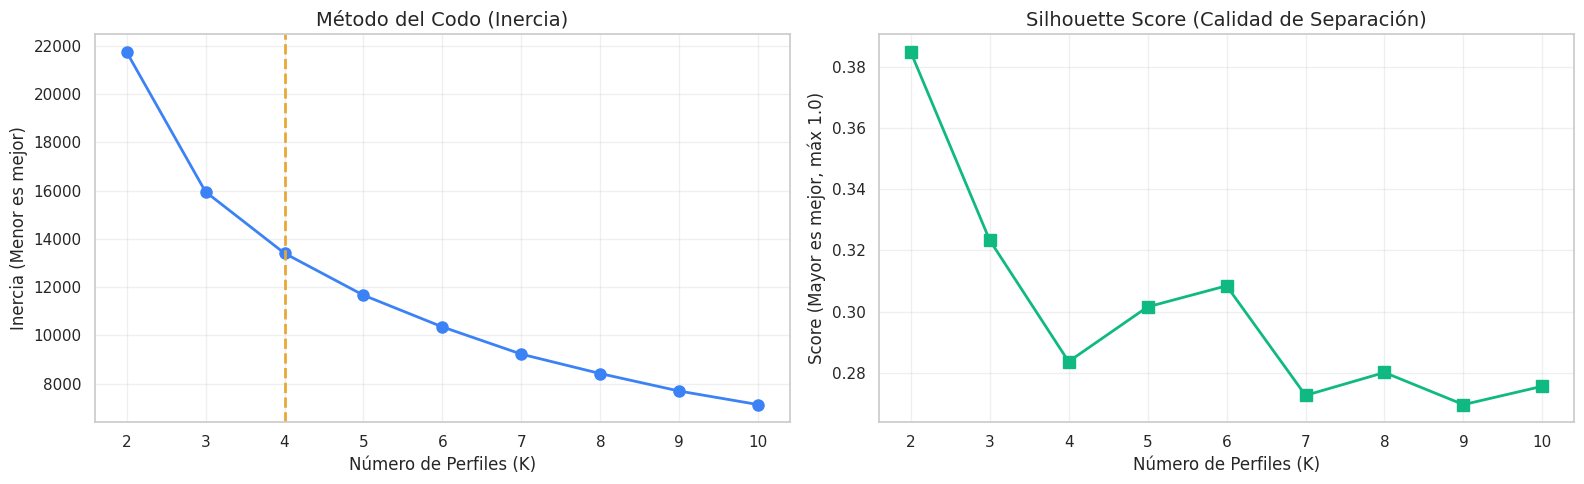


💡 CONCLUSIÓN MATEMÁTICA AUTOMÁTICA:
El Silhouette Score más alto se alcanzó con K = 2


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# ==========================================
# 1. PREPARACIÓN E INGENIERÍA DE DATOS
# ==========================================
# Seleccionamos las columnas base
columnas_cluster = ['Cant.', 'P.Prom', '$Base', '$Final']
df_kmeans = df_total[columnas_cluster].copy()

# Nos aseguramos de que todo sea numérico y eliminamos nulos
for col in columnas_cluster:
    df_kmeans[col] = pd.to_numeric(df_kmeans[col], errors='coerce')
df_kmeans = df_kmeans.dropna()

# Creamos nuestra variable estrella: El Termómetro de Puja
df_kmeans['Margen_Puja'] = df_kmeans['$Final'] - df_kmeans['$Base']

# Seleccionamos las pistas finales para el algoritmo
X_cluster = df_kmeans[['P.Prom', '$Final', 'Margen_Puja']]

# ==========================================
# 2. ESCALAMIENTO (Obligatorio para K-Means)
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ==========================================
# 3. EL JURADO MATEMÁTICO (Evaluando K de 2 a 10)
# ==========================================
inercia = []
valores_silueta = []
rango_k = range(2, 11)

for k in rango_k:
    # Entrenamos un modelo temporal para cada K
    modelo_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas_temp = modelo_temp.fit_predict(X_scaled)

    # Guardamos la Inercia (para la curva del codo)
    inercia.append(modelo_temp.inertia_)

    # Guardamos el Silhouette Score (Calidad de separación)
    score_silueta = silhouette_score(X_scaled, etiquetas_temp)
    valores_silueta.append(score_silueta)

# ==========================================
# 4. VISUALIZACIÓN DE LOS EXÁMENES
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfica 1: Método del Codo
ax1.plot(rango_k, inercia, marker='o', color='#3b82f6', linewidth=2, markersize=8)
ax1.set_title('Método del Codo (Inercia)', fontsize=14)
ax1.axvline(x=4, color='#E8A838', linestyle='--', linewidth=2, label='Codo sugerido: K=4')
ax1.set_xlabel('Número de Perfiles (K)', fontsize=12)
ax1.set_ylabel('Inercia (Menor es mejor)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(rango_k)

# Gráfica 2: Silhouette Score
ax2.plot(rango_k, valores_silueta, marker='s', color='#10b981', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score (Calidad de Separación)', fontsize=14)
ax2.set_xlabel('Número de Perfiles (K)', fontsize=12)
ax2.set_ylabel('Score (Mayor es mejor, máx 1.0)', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(rango_k)

plt.tight_layout()
plt.show()

# Imprimir el mejor K sugerido matemáticamente
mejor_k = rango_k[valores_silueta.index(max(valores_silueta))]
print(f"\n💡 CONCLUSIÓN MATEMÁTICA AUTOMÁTICA:")
print(f"El Silhouette Score más alto se alcanzó con K = {mejor_k}")

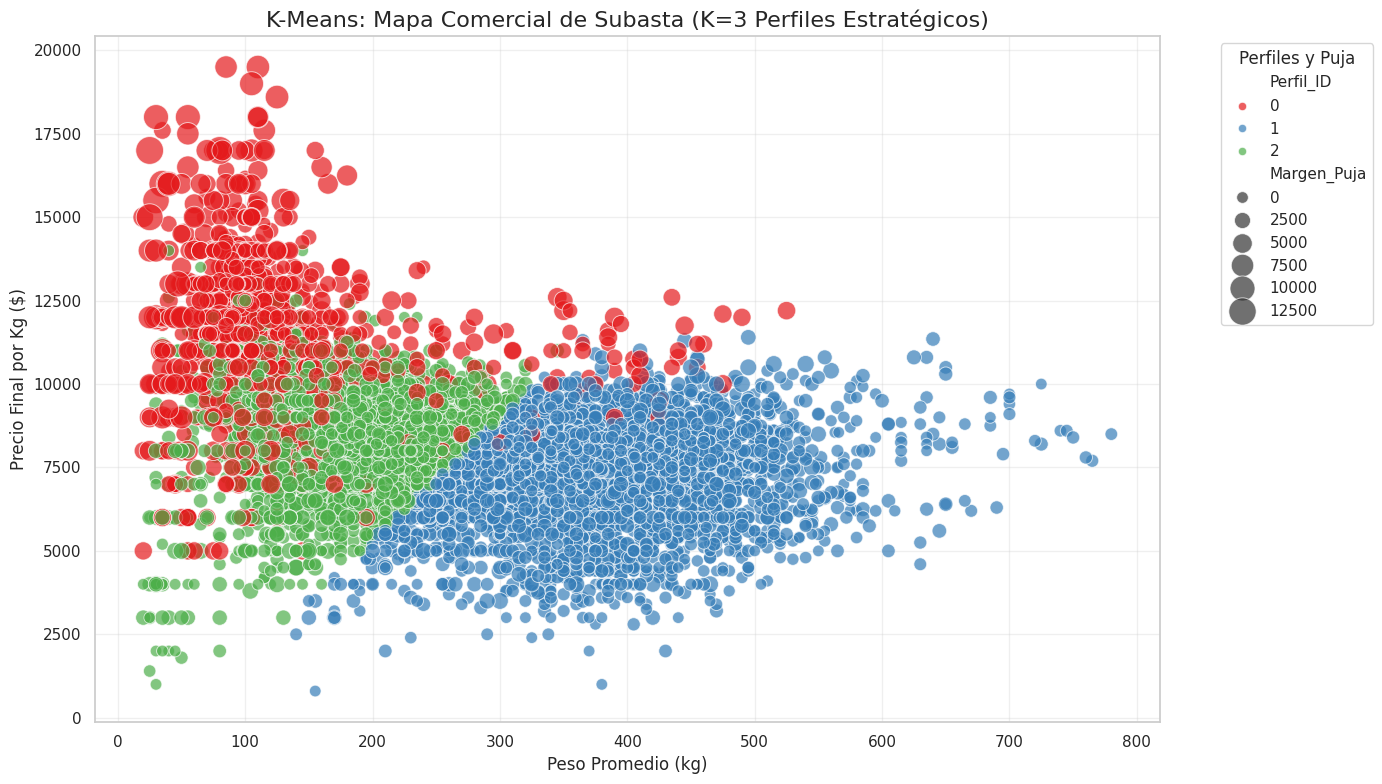


--- PROMEDIOS DE LOS PERFILES COMERCIALES ---
           P.Prom   $Final  Margen_Puja  Cant.
Perfil_ID                                     
0           122.2  11389.4       3157.7    1.7
1           370.1   7418.1        771.2    1.5
2           178.8   8696.8        761.2    2.4


In [17]:
# ==========================================
# 5. DECISIÓN DE NEGOCIO (Business Override)
# ==========================================
# Anulamos el K=2 matemático y forzamos K=3 para obtener perfiles accionables.
k_estrategico = 3

modelo_kmeans_final = KMeans(n_clusters=k_estrategico, random_state=10, n_init=10)
df_kmeans['Perfil_ID'] = modelo_kmeans_final.fit_predict(X_scaled)

# ==========================================
# 6. EL MAPA COMERCIAL (Gráfico de Dispersión)
# ==========================================
plt.figure(figsize=(14, 8))

# Creamos el gráfico de burbujas
grafico = sns.scatterplot(
    data=df_kmeans,
    x='P.Prom',
    y='$Final',
    hue='Perfil_ID',
    size='Margen_Puja',
    sizes=(20, 400), # Ajusta el tamaño mínimo y máximo de las burbujas
    palette='Set1',
    alpha=0.7
)

# Configuramos los textos y el diseño
plt.title(f'K-Means: Mapa Comercial de Subasta (K={k_estrategico} Perfiles Estratégicos)', fontsize=16)
plt.xlabel('Peso Promedio (kg)', fontsize=12)
plt.ylabel('Precio Final por Kg ($)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Perfiles y Puja")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# ==========================================
# 7. RESUMEN GERENCIAL PARA BAUTIZAR PERFILES
# ==========================================
resumen = df_kmeans.groupby('Perfil_ID')[['P.Prom', '$Final', 'Margen_Puja', 'Cant.']].mean().round(1)
print("\n--- PROMEDIOS DE LOS PERFILES COMERCIALES ---")
print(resumen)

**Perfiles de compradores (3):**


1.  Perfil 0 (Rojo),  : "Destete precoz Premium" (< 150Kgs), Peso Promedio de 122.2 kg, Precio altísimo de 11,389, y un Margen de Puja brutal de 3.157. Lotes pequeños (1.7 animales). Una puja de un lote de ganado pequeño no vale tanto en dinero como en ganado gordo, inversamente proporcional
2.  Perfil 1 (Azul): "Mercado de Frigorifico", Peso de 370.1Kgs, margen de puja muy cerrado: 771.2, a mayor peso menos margen de pujas, el comprador va con calculadora en mano referido por los precios de la carne. En estas compras es comun ver Pujas de 100, de 50 y hasta de 20 pesos para concretar la venta.
3.  Perfil 2 (Verde): "Destete Numeroso y Homogeneo" Peso de 178.8 kg, Lotes mas numerosos, de 2.4 animales en promedio por lote, Precio de 8,696, Margen de Puja bajo de $761,2. Se relaciona con los animales destetados, que en el mercado rondan los 160 a 180Kgs en promedio

# **Conclusiones y Recomendaciones:**
Los resultados del modelo de regresion lineal, con un acierto hasta del 29%, aunque en general es muy bajo, creemos que es muy aterrizado a la realidad del mercado ganadero. Ya que en la data no contamos con variables que influyen mucho en los precios de ciertas categorias (preñez, cantidad de partos, biotipo:leche/carne, edad, entre otros). En un futuro, si al momento de la recepcion del ganado la empresa puede recolectar mas datos/variables, podemos considerar implementarlo en produccion. El modelo de clasificacion nos llama la atencion para tener en las distintas categorias un precio mas acertado, lo que ayudaria mucho a ahorrar tiempos en la parte operativa de la venta.



Por ultimo, la segmentacion (Clusteting/K-Means) es el apartado que mas nos llama la atencion, para una posible implementacion. Actualmente se crean listas de difusion de WhatsApp, donde los clientes nuevos a medida que van llegando se van agregando, sin crear estrategias para los distintos 3 perfiles que vimos en el apartado de este modelo: Levante Premium, Detete Numeroso y Ganado Gordo.